In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import files
import io

In [ ]:
uploaded = files.upload()

Saving AmesHousing.xlsx to AmesHousing.xlsx


In [ ]:
data = pd.read_excel(io.BytesIO(uploaded['AmesHousing.xlsx']))

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 79 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Area         2930 non-null   int64  
 3   Street           2930 non-null   object 
 4   Alley            198 non-null    object 
 5   Lot Shape        2930 non-null   object 
 6   Land Contour     2930 non-null   object 
 7   Utilities        2930 non-null   object 
 8   Lot Config       2930 non-null   object 
 9   Land Slope       2930 non-null   object 
 10  Neighborhood     2930 non-null   object 
 11  Condition 1      2930 non-null   object 
 12  Condition 2      2930 non-null   object 
 13  Bldg Type        2930 non-null   object 
 14  House Style      2930 non-null   object 
 15  Overall Qual     2930 non-null   int64  
 16  Overall Cond     2930 non-null   int64  
 17  Year Built    

In [ ]:
# 데이터 결측치 50%이상 제거 편향되어있는 값들 제거
missing_ratio = data.isnull().mean()
drop_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

single_value_cols = [
    col for col in data.columns
    if data[col].nunique() == 1 or data[col].value_counts(normalize=True).iloc[0] > 0.95
]

id_cols = ['Order', 'PID'] if 'PID' in data.columns else ['Order']
remove_cols = list(set(drop_missing_cols + single_value_cols + id_cols))

# 필요없는 변수 제거 및 제거 지하나 차고 없으면 0

data_cleaned = data.drop(columns=remove_cols).copy()
data_cleaned['Total Bsmt SF'] = data_cleaned['Total Bsmt SF'].fillna(0)
data_cleaned['Garage Area'] = data_cleaned['Garage Area'].fillna(0)

# 수치형 변수의 Null값은 중앙값으로 대체
num_cols = data_cleaned.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col != 'SalePrice']

for col in num_cols:
    if data_cleaned[col].isnull().any():
        data_cleaned[col] = data_cleaned[col].fillna(data_cleaned[col].median())

# 범주형 변수 NuLL값 최빈값으로 대체
cat_cols = data_cleaned.select_dtypes(include='object').columns
for col in cat_cols:
    if data_cleaned[col].isnull().any():
        data_cleaned[col] = data_cleaned[col].fillna(data_cleaned[col].mode()[0])


print(f"최종 컬럼 수: {data_cleaned.shape[1]}")
print(f"결측치 남은 컬럼: {data_cleaned.isnull().sum().loc[lambda x: x>0].shape[0]}개")
print(data_cleaned.head(3))

최종 컬럼 수: 61
결측치 남은 컬럼: 0개
  MS Zoning  Lot Area Lot Shape Land Contour Lot Config Neighborhood  \
0        RL     31770       IR1          Lvl     Corner        NAmes   
1        RH     11622       Reg          Lvl     Inside        NAmes   
2        RL     14267       IR1          Lvl     Corner        NAmes   

  Condition 1 Bldg Type House Style  Overall Qual  ...  Paved Drive  \
0        Norm      1Fam      1Story             6  ...            P   
1       Feedr      1Fam      1Story             5  ...            Y   
2        Norm      1Fam      1Story             6  ...            Y   

   Wood Deck SF  Open Porch SF Enclosed Porch Screen Porch Mo Sold  Yr Sold  \
0           210             62              0            0       5     2010   
1           140              0              0          120       6     2010   
2           393             36              0            0       6     2010   

  Sale Type Sale Condition SalePrice  
0       WD          Normal    215000  
1    

In [ ]:
# 범주형 변수 원-핫 인코딩과 True/false -> 1/0으로 만들기.
data_cleaned['Log_SalePrice'] = np.log1p(data_cleaned['SalePrice'])

data_encoded = pd.get_dummies(data_cleaned)

bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

X = data_encoded.drop(columns=['SalePrice', 'Log_SalePrice'])
y = data_encoded['Log_SalePrice']

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

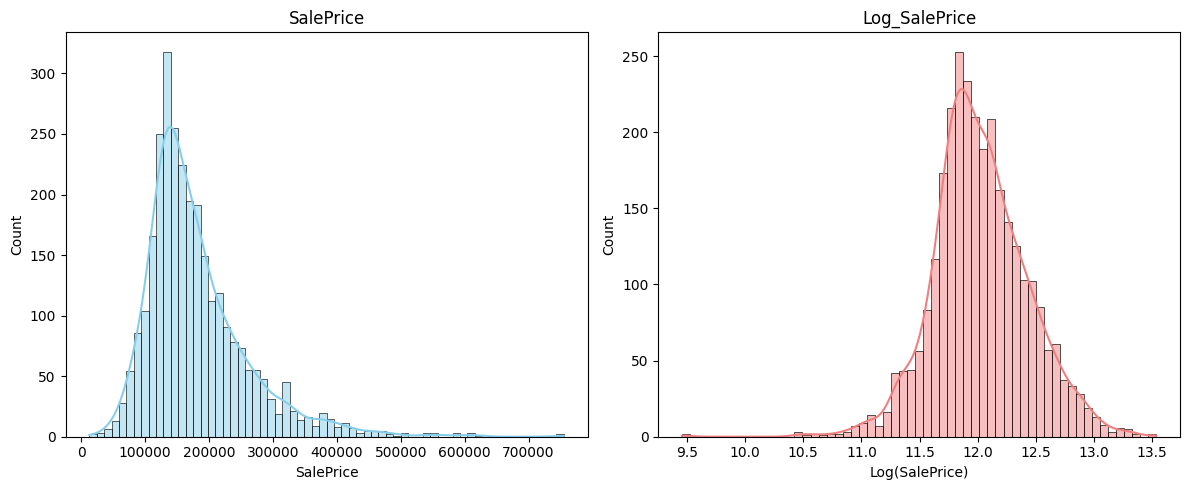

In [ ]:
# 그래프 크기 설정
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data_cleaned['SalePrice'], kde=True, color='skyblue')
plt.title('SalePrice')
plt.xlabel('SalePrice')

# 로그 변환된 SalePrice 분포
plt.subplot(1, 2, 2)
sns.histplot(data_cleaned['Log_SalePrice'], kde=True, color='lightcoral')
plt.title('Log_SalePrice')
plt.xlabel('Log(SalePrice)')

plt.tight_layout()

plt.savefig('SalePrice.png', dpi=300, bbox_inches='tight')

files.download('SalePrice.png')

plt.show()


In [ ]:
print(X)

      Lot Area  Overall Qual  Overall Cond  Year Built  Year Remod/Add  \
0        31770             6             5        1960            1960   
1        11622             5             6        1961            1961   
2        14267             6             6        1958            1958   
3        11160             7             5        1968            1968   
4        13830             5             5        1997            1998   
...        ...           ...           ...         ...             ...   
2925      7937             6             6        1984            1984   
2926      8885             5             5        1983            1983   
2927     10441             5             5        1992            1992   
2928     10010             5             5        1974            1975   
2929      9627             7             5        1993            1994   

      Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  Total Bsmt SF  \
0            112.0         639.0 

In [ ]:
# 데이터 분할 8:2 비율, 모델 = 랜텀포레스트(회귀)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rfr = RandomForestRegressor(n_estimators=100, random_state=42)
model_rfr.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
# 예측
y_pred_log = model_rfr.predict(X_test)

# 복원
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [ ]:
# 고평가/저평가 탐지
results = data_cleaned.loc[y_test.index].copy()
results['Predicted_Price'] = y_pred
results['Rest'] = results['SalePrice'] - results['Predicted_Price']

results['Evaluation'] = results['Rest'].apply(
    lambda x: '저평가' if x > 10000 else ('고평가' if x < -10000 else '적정')
)

print(results[['SalePrice', 'Predicted_Price', 'Rest', 'Evaluation']].head())

      SalePrice  Predicted_Price          Rest Evaluation
1357     161000    168921.418018  -7921.418018         적정
2367     116000    100963.204904  15036.795096        저평가
2822     196500    189958.427726   6541.572274         적정
2126     123600    119175.463004   4424.536996         적정
1544     126000    107764.054662  18235.945338        저평가


In [ ]:
# 모델 성능 평가
def evaluate_model(y_true, y_pred_log, model_name="모델"):
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_true)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"[{model_name}] 성능 평가 (실제 SalePrice 기준)")
    print(f"RMSE : {rmse:.0f}원")
    print(f"MAE  : {mae:.0f}원")
    print(f"R^2   : {r2:.4f}")


In [ ]:
evaluate_model(y_test, y_pred_log, model_name="RandomForestRegressor")

[RandomForestRegressor] 성능 평가 (실제 SalePrice 기준)
RMSE : 27462원
MAE  : 16152원
R^2   : 0.9059


In [ ]:
print(results['Evaluation'].value_counts())
print(results['Evaluation'].value_counts(normalize=True) * 100)  # %

Evaluation
적정     291
저평가    169
고평가    126
Name: count, dtype: int64
Evaluation
적정     49.658703
저평가    28.839590
고평가    21.501706
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

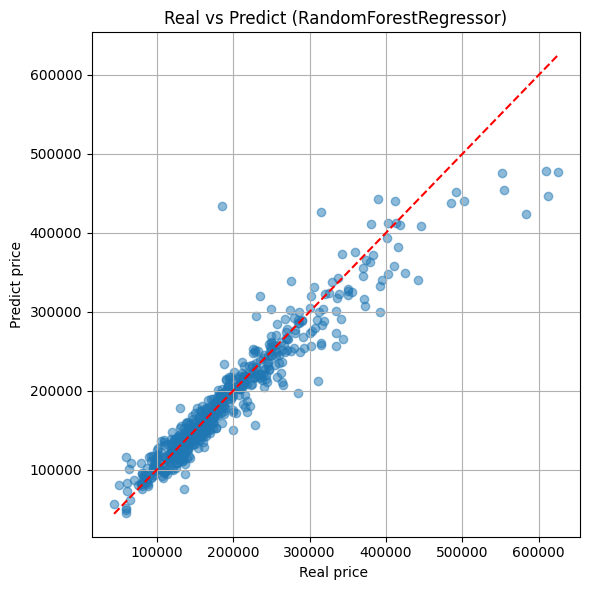

In [ ]:
# 시각화
plt.figure(figsize=(6,6))
plt.scatter(results['SalePrice'], results['Predicted_Price'], alpha=0.5)
plt.plot([results['SalePrice'].min(), results['SalePrice'].max()],
         [results['SalePrice'].min(), results['SalePrice'].max()],
         'r--')
plt.xlabel("Real price ")
plt.ylabel("Predict price")
plt.title("Real vs Predict (RandomForestRegressor)")
plt.grid(True)
plt.tight_layout()

plt.savefig('SalePrice_RFR.png', dpi=300, bbox_inches='tight')

files.download('SalePrice_RFR.png')

plt.show()

In [ ]:
# XGBoost
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_log = model_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [ ]:
# 고평가/저평가 탐지
results = data_cleaned.loc[y_test.index].copy()
results['Predicted_Price'] = y_pred
results['Rest'] = results['SalePrice'] - results['Predicted_Price']

results['Evaluation'] = results['Rest'].apply(
    lambda x: '저평가' if x > 10000 else ('고평가' if x < -10000 else '적정')
)

print(results[['SalePrice', 'Predicted_Price', 'Rest', 'Evaluation']].head())

      SalePrice  Predicted_Price          Rest Evaluation
1357     161000    172690.218750 -11690.218750        고평가
2367     116000    102175.031250  13824.968750        저평가
2822     196500    181611.500000  14888.500000        저평가
2126     123600    123373.710938    226.289062         적정
1544     126000    112609.367188  13390.632812        저평가


In [ ]:
# XGBoost 성능 평가
def evaluate_model(y_true_log, y_pred_log, model_name="XGBoost"):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"[{model_name}] 성능 평가")
    print(f"RMSE : {rmse:.0f}원")
    print(f"MAE  : {mae:.0f}원")
    print(f"R^2   : {r2:.4f}")

# 평가 실행
evaluate_model(y_test, y_pred_log, model_name="XGBoost Regressor")

[XGBoost Regressor] 성능 평가
RMSE : 24294원
MAE  : 14654원
R^2   : 0.9264


In [ ]:
print(results['Evaluation'].value_counts())
print(results['Evaluation'].value_counts(normalize=True) * 100)  # %

Evaluation
적정     309
저평가    152
고평가    125
Name: count, dtype: int64
Evaluation
적정     52.730375
저평가    25.938567
고평가    21.331058
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

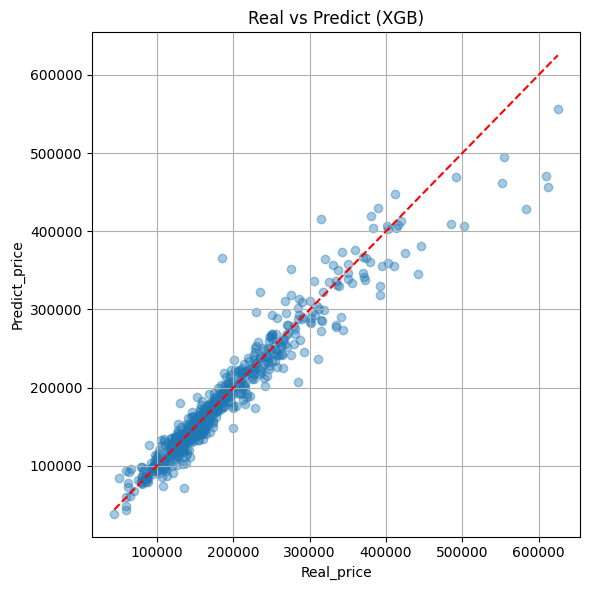

In [ ]:
#시각화
plt.figure(figsize=(6,6))
plt.scatter(results['SalePrice'], results['Predicted_Price'], alpha=0.4)
plt.plot([results['SalePrice'].min(), results['SalePrice'].max()],
         [results['SalePrice'].min(), results['SalePrice'].max()],
         'r--')
plt.xlabel("Real_price")
plt.ylabel("Predict_price")
plt.title("Real vs Predict (XGB)")
plt.grid(True)
plt.tight_layout()


plt.savefig('SalePrice_XGB.png', dpi=200, bbox_inches='tight')

files.download('SalePrice_XGB.png')

plt.show()